In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install -r "/content/drive/MyDrive/Zindi_Maize_Prediction_Challenge/requirements.txt"

In [3]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [12]:
#modelling_results/1770814695098/model_h1_catboost.pkl
#modelling_results/1770814695098/model_h2_mlp.pkl
MAIN_PATH = "/content/drive/MyDrive/Zindi_Maize_Prediction_Challenge/"
MODEL_DIR = MAIN_PATH + "modelling_results/1770818034530"
FEATURE_MATRIX = MAIN_PATH + "data/processed_data.csv"

#Target counties and commodity class
TARGET_COUNTIES = ["Kiambu", "Kirinyaga", "Mombasa", "Nairobi", "Uasin-Gishu"]

In [13]:
#best models from modelling
best_models = {1: "catboost", 2: "mlp"}

In [14]:
processed_data = pd.read_csv(FEATURE_MATRIX)

In [15]:
processed_data['date'] = pd.to_datetime(processed_data['date'])

In [16]:
def get_default_feature_spec(df):
    """
    Identifies available features from a predefined list of high-value predictors.

    This ensures that the model only attempts to use columns that exist in the
    current dataset, maintaining stability between training and inference.

    Args:
        df (pd.DataFrame): The dataset to check for feature columns.

    Returns:
        tuple[list, list]: (categorical_columns, numerical_columns)
    """
    preferred_num = [
        # agriBORA features
        "wholesale","prev_price","prev2_price","gap1_weeks","gap2_weeks","slope1",
        "iso_week","wk_sin","wk_cos","is_year_end",

        # KAMIS lag features (national + county fallback)
        "k_nat_wh_lag1","k_nat_supply_lag1","k_nat_rt_lag1",
        "k_wh_lag1","k_supply_lag1","k_rt_lag1"
    ]
    cat_cols = ["county"]
    num_cols = [c for c in preferred_num if c in df.columns]
    cat_cols = [c for c in cat_cols if c in df.columns]
    return cat_cols, num_cols

In [17]:
def forecast_from_saved_models(ag_feat, anchor_date, forecast_dates, best_models, model_dir=MODEL_DIR):
    """
    Generates forecasts using pre-trained .pkl models.

    Args:
        ag_feat: Feature panel containing data for the anchor_date.
        anchor_date: The date to project from.
        forecast_dates: List of future dates (h=1, h=2, etc.).
        best_models: Dict mapping horizon to model kind {1: "catboost", ...}.
        model_dir: Directory where .pkl files are stored.
    """
    out = {}

    # Identify features used during training
    # Note: Ensure this matches the list in your training script!
    cat_cols, num_cols = get_default_feature_spec(ag_feat)

    for h, td in enumerate(forecast_dates, start=1):
        mk = best_models[h]
        model_path = f"{model_dir}/model_h{h}_{mk}.pkl"

        # 1. Load the saved model/pipeline
        model = joblib.load(model_path)

        # 2. Get anchor rows (current state of each county)
        anchor_rows = ag_feat[ag_feat["date"] == anchor_date].copy()

        # Fallback for missing counties at anchor date
        for c in TARGET_COUNTIES:
            if not (anchor_rows["county"] == c).any():
                last_row = ag_feat[(ag_feat["county"] == c) &
                                   (ag_feat["date"] < anchor_date)].sort_values("date").tail(1)
                anchor_rows = pd.concat([anchor_rows, last_row], ignore_index=True)

        # 3. Predict the Delta
        X_va = anchor_rows[cat_cols + num_cols]
        pred_delta = model.predict(X_va)

        # 4. Reconstruct Level
        y_anchor = anchor_rows["wholesale"].astype(float).values
        pred_level = y_anchor + pred_delta

        for c, yhat in zip(anchor_rows["county"].tolist(), pred_level.tolist()):
            out[(c, pd.Timestamp(td))] = float(yhat)

    return out

In [18]:
def get_feature_importance_from_saved(model_path, model_kind, feature_names):
    """
    Extracts and maps feature importance scores from a saved model file.

    This function handles the structural differences between CatBoost models
    and Scikit-Learn Pipelines (which require accessing the 'model' step).

    Args:
        model_path (str): Path to the .pkl file.
        model_kind (str): The kind of model ('catboost', 'ridge', 'hgb', etc.).
        feature_names (list): The list of features passed to the model (cat + num).

    Returns:
        pd.DataFrame: A DataFrame with 'feature' and 'importance' columns,
            sorted by importance descending.
    """
    # Load the saved object
    m = joblib.load(model_path)

    importance_values = None

    if model_kind == "catboost":
        # CatBoost has a direct method for this
        importance_values = m.get_feature_importance()

    elif model_kind == "hgb":
        # HistGradientBoosting doesn't have a coef_ or feature_importances_ attribute
        # in the same way, but it does have 'feature_importances_' in newer versions.
        # Note: We must access the 'model' step from the Pipeline
        importance_values = m.named_steps["model"].feature_importances_

    elif model_kind in ["ridge", "elasticnet"]:
        # Linear models use coefficients as a proxy for importance
        # Note: These should be interpreted as 'magnitude of impact'
        importance_values = np.abs(m.named_steps["model"].coef_)

    elif model_kind == "mlp":
        # MLPs (Neural Nets) don't have simple feature importance.
        # We approximate it by summing the weights of the first hidden layer.
        weights = m.named_steps["model"].coefs_[0]
        importance_values = np.mean(np.abs(weights), axis=1)

    if importance_values is None:
        raise ValueError(f"Feature importance not supported for {model_kind}")

    # For models with OneHotEncoding (sklearn pipelines), the number of features
    # will increase. We handle the mapping here:
    if model_kind != "catboost":
        # Get the names after the preprocessor transformation (handles OneHot names)
        final_cols = m.named_steps["pre"].get_feature_names_out()
    else:
        final_cols = feature_names

    df_imp = pd.DataFrame({
        "feature": final_cols,
        "importance": importance_values
    }).sort_values("importance", ascending=False)

    return df_imp

# SUBMISISON

In [19]:
ANCHOR_DATE = pd.Timestamp("2025-12-15")
FORECAST_DATES = [pd.Timestamp("2025-12-22"), pd.Timestamp("2025-12-29")]
best_models = {1: "catboost", 2: "mlp"}

# Run this for fast daily/weekly inference
pred_map = forecast_from_saved_models(
    ag_feat=processed_data,
    anchor_date=ANCHOR_DATE,
    forecast_dates=FORECAST_DATES,
    best_models=best_models,
    model_dir=MODEL_DIR
)

In [20]:
# View predictions
pred_df = pd.DataFrame([
    {"County": c, "TargetDate": d, "Predicted": y}
    for (c, d), y in pred_map.items()
]).sort_values(["County","TargetDate"])

pred_df

,County,TargetDate,Predicted
0,Kiambu,2025-12-22,45.114726
5,Kiambu,2025-12-29,46.059671
1,Kirinyaga,2025-12-22,46.579991
6,Kirinyaga,2025-12-29,47.804861
2,Mombasa,2025-12-22,41.953479
7,Mombasa,2025-12-29,44.225861
3,Nairobi,2025-12-22,42.807835
8,Nairobi,2025-12-29,45.198868
4,Uasin-Gishu,2025-12-22,41.942942
9,Uasin-Gishu,2025-12-29,43.616451


In [21]:
#Create the submission file
def iso_week_number(d):
    return int(pd.Timestamp(d).isocalendar().week)

rows = []
for (c, d), y in pred_map.items():
    wk = iso_week_number(d)  # 52 or 1 (ISO week for 2025-12-29 is often 1)
    # If they explicitly want Week 53, override:
    if pd.Timestamp(d) == pd.Timestamp("2025-12-29"):
        wk = 1

    rows.append({
        "ID": f"{c}_Week_{wk}",      # no leading zeros
        "Target_RMSE": float(y),
        "Target_MAE": float(y),
    })

sub = pd.DataFrame(rows).sort_values("ID")
sub


,ID,Target_RMSE,Target_MAE
5,Kiambu_Week_1,46.059671,46.059671
0,Kiambu_Week_52,45.114726,45.114726
6,Kirinyaga_Week_1,47.804861,47.804861
1,Kirinyaga_Week_52,46.579991,46.579991
7,Mombasa_Week_1,44.225861,44.225861
2,Mombasa_Week_52,41.953479,41.953479
8,Nairobi_Week_1,45.198868,45.198868
3,Nairobi_Week_52,42.807835,42.807835
9,Uasin-Gishu_Week_1,43.616451,43.616451
4,Uasin-Gishu_Week_52,41.942942,41.942942


In [22]:
#save_submission
sub.to_csv(MODEL_DIR + "/submission.csv",index=False)

## FEATURE IMPORTANCE

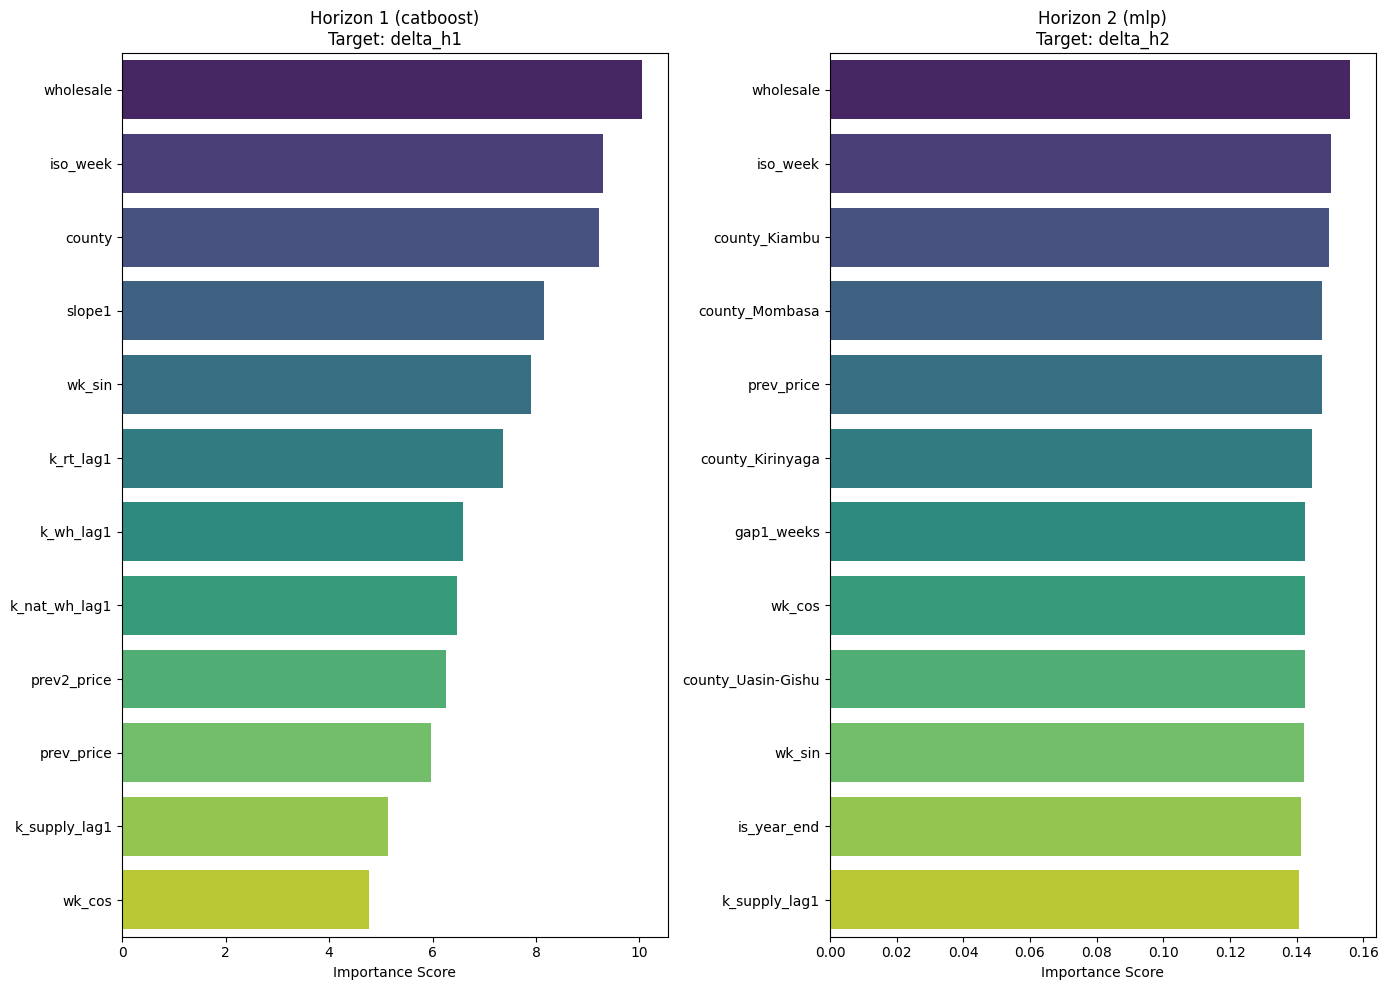

In [23]:
def plot_multi_horizon_importance(best_models, processed_data, model_dir=MODEL_DIR, top_n=15):
    """
    Loads saved models for all horizons and plots their feature importances.

    Args:
        best_models (dict): The mapping used during training, e.g., {1: "catboost", 2: "mlp"}.
        ag_feat (pd.DataFrame): The feature dataframe used to retrieve column names.
        model_dir (str): Directory where .pkl files are stored.
        top_n (int): Number of top features to show for each horizon.
    """
    cat_cols, num_cols = get_default_feature_spec(processed_data)
    all_feats = cat_cols + num_cols

    # Setup the figure with one subplot per horizon
    fig, axes = plt.subplots(1, len(best_models), figsize=(14, 10), sharey=False)
    if len(best_models) == 1: axes = [axes] # Handle single horizon case

    for i, (h, mk) in enumerate(best_models.items()):
        path = f"{model_dir}/model_h{h}_{mk}.pkl"

        try:
            # Reuse our extraction logic from earlier
            df_imp = get_feature_importance_from_saved(path, mk, all_feats)

            # Take top N for clarity
            plot_data = df_imp.head(top_n)

            sns.barplot(
                data=plot_data,
                x="importance",
                y="feature",
                ax=axes[i],
                palette="viridis"
            )
            axes[i].set_title(f"Horizon {h} ({mk})\nTarget: delta_h{h}")
            axes[i].set_xlabel("Importance Score")
            axes[i].set_ylabel("")

        except FileNotFoundError:
            axes[i].text(0.5, 0.5, f"File not found:\n{path}", ha='center')

    plt.tight_layout()
    plt.show()

# Execution
plot_multi_horizon_importance(best_models, processed_data, top_n=12)